# Decision Tree Classification — Airline Customer Satisfaction Prediction

**Business Goal**: Predict whether a passenger is `satisfied` or `dissatisfied` using Invistico Airline survey data (129,880 rows). Tune a Decision Tree with GridSearchCV, visualize the tree, extract feature importance scores, and compare against Logistic Regression for airline management stakeholders.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, f1_score, accuracy_score,
                              precision_score, recall_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
print("Libraries loaded OK.")

Libraries loaded OK.


## 1. Load Dataset and Prepare Features

In [2]:
df = pd.read_csv('Invistico_Airline.csv')
print("Shape:", df.shape)
print()
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum()>0])
print()
print("Target distribution:")
print(df['satisfaction'].value_counts())

Shape: (129880, 22)

Missing values:
Arrival Delay in Minutes    393
dtype: int64

Target distribution:
satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64


In [3]:
# Impute missing arrival delay with median
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Arrival Delay in Minutes'].median())

# Encode target: satisfied=1, dissatisfied=0
df['satisfaction'] = df['satisfaction'].map({'satisfied':1,'dissatisfied':0})

# Encode binary categoricals
df['Customer Type'] = df['Customer Type'].map({'Loyal Customer':1,'disloyal Customer':0})
df['Type of Travel'] = df['Type of Travel'].map({'Business travel':1,'Personal Travel':0})

# One-hot encode Class (3 categories)
df = pd.get_dummies(df, columns=['Class'], drop_first=True)
df = df.astype(float)  # ensure all numeric

print("Encoding complete. Shape:", df.shape)
print("Null check:", df.isnull().sum().sum())
print("Features:", df.drop(columns=['satisfaction']).columns.tolist())

Encoding complete. Shape: (129880, 23)
Null check: 0
Features: ['Customer Type', 'Age', 'Type of Travel', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Class_Eco', 'Class_Eco Plus']


## 2. Train/Test Split (75/25 stratified)

In [4]:
X = df.drop(columns=['satisfaction'])
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print("Train class balance:", y_train.value_counts(normalize=True).round(3).to_dict())

Train: 97,410 | Test: 32,470
Train class balance: {1.0: 0.547, 0.0: 0.453}


## 3. GridSearchCV — Hyperparameter Tuning

In [5]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 10, 50],
    'min_samples_leaf': [1, 5, 20],
    'criterion': ['gini', 'entropy']
}

total = 1
for v in param_grid.values(): total *= len(v)
print(f"Grid: {total} combinations x 5-fold CV = {total*5} fits")
print("Params:", param_grid)

Grid: 90 combinations x 5-fold CV = 450 fits
Params: {'max_depth': [3, 5, 7, 10, 15], 'min_samples_split': [2, 10, 50], 'min_samples_leaf': [1, 5, 20], 'criterion': ['gini', 'entropy']}


In [6]:
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0,
    refit=True
)
grid_search.fit(X_train, y_train)

print("GridSearchCV complete.")
print("Best parameters found:")
for k,v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV F1-score: {grid_search.best_score_:.4f}")

GridSearchCV complete.
Best parameters found:
  criterion: gini
  max_depth: 15
  min_samples_leaf: 1
  min_samples_split: 10
Best CV F1-score: 0.9434


In [7]:
# Top 10 results from grid search
cv_df = pd.DataFrame(grid_search.cv_results_)
top10 = cv_df[['param_max_depth','param_min_samples_split','param_min_samples_leaf',
                'param_criterion','mean_test_score','std_test_score']].sort_values(
    'mean_test_score', ascending=False).head(10)
top10.columns = ['max_depth','min_samples_split','min_samples_leaf','criterion','mean_F1','std_F1']
top10 = top10.round(4)
print("Top 10 hyperparameter combinations by CV F1:")
print(top10.to_string(index=False))

Top 10 hyperparameter combinations by CV F1:
 max_depth  min_samples_split  min_samples_leaf criterion  mean_F1  std_F1
        15                 10                 1      gini   0.9434  0.0023
        15                 10                 1   entropy   0.9431  0.0010
        15                 50                 1      gini   0.9428  0.0018
        15                  2                 1      gini   0.9426  0.0019
        15                  2                 1   entropy   0.9425  0.0014
        15                 10                 5   entropy   0.9424  0.0011
        15                  2                 5   entropy   0.9424  0.0011
        15                  2                 5      gini   0.9424  0.0016
        15                 10                 5      gini   0.9424  0.0016
        15                 50                 5      gini   0.9421  0.0015


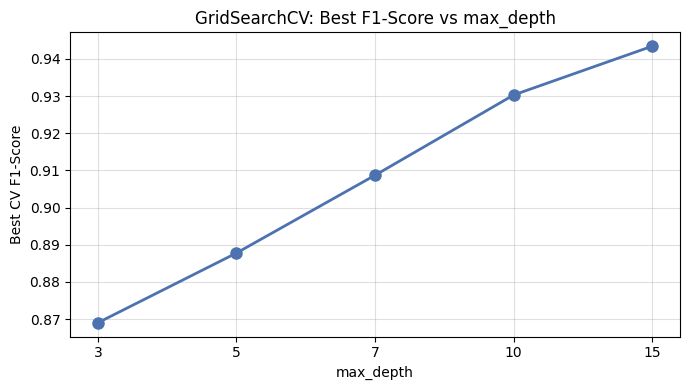

Chart saved.


In [8]:
# Plot F1 vs max_depth
depth_f1 = cv_df.groupby('param_max_depth')['mean_test_score'].max().reset_index()
depth_f1.columns = ['max_depth','best_f1']

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(depth_f1['max_depth'].astype(str), depth_f1['best_f1'],
        marker='o', color='#4C72B0', linewidth=2, markersize=8)
ax.set_xlabel('max_depth')
ax.set_ylabel('Best CV F1-Score')
ax.set_title('GridSearchCV: Best F1-Score vs max_depth')
ax.grid(True, alpha=0.4)
for i, row in depth_f1.iterrows():
    ax.annotate(f"{row['best_f1']:.3f}", (str(row['max_depth']), row['best_f1']),
                textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('gridsearch_f1.png', dpi=100)
plt.show()
print("Chart saved.")

## 4. Train Final Decision Tree with Best Hyperparameters

In [9]:
best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)
y_pred_proba = best_dt.predict_proba(X_test)[:,1]

print(f"Tree depth (actual): {best_dt.get_depth()}")
print(f"Number of leaves:    {best_dt.get_n_leaves()}")

Tree depth (actual): 15
Number of leaves:    1404


## 5. Confusion Matrix and F1-Score

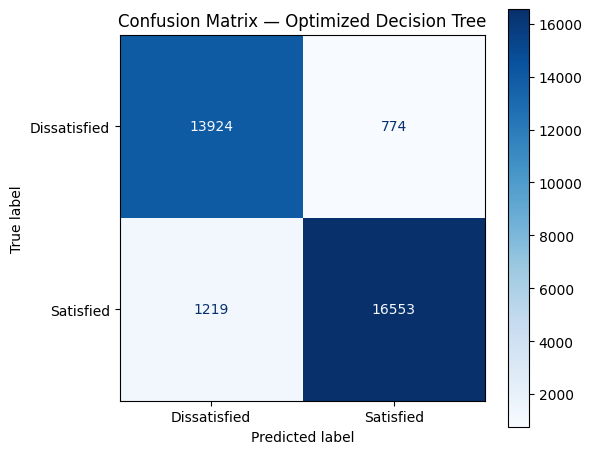

True Negatives  (Dissatisfied correct): 13,924
False Positives (Dissatisfied -> Satisfied): 774
False Negatives (Satisfied -> Dissatisfied): 1,219
True Positives  (Satisfied correct): 16,553


In [10]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Dissatisfied','Satisfied'])
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('Confusion Matrix — Optimized Decision Tree')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Dissatisfied correct): {tn:,}")
print(f"False Positives (Dissatisfied -> Satisfied): {fp:,}")
print(f"False Negatives (Satisfied -> Dissatisfied): {fn:,}")
print(f"True Positives  (Satisfied correct): {tp:,}")

In [11]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:              {acc:.4f}")
print(f"Precision (Satisfied): {prec:.4f}")
print(f"Recall (Satisfied):    {rec:.4f}")
print(f"F1-Score (Satisfied):  {f1:.4f}  << PRIMARY METRIC")
print(f"ROC-AUC:               {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Dissatisfied','Satisfied']))

Accuracy:              0.9386
Precision (Satisfied): 0.9553
Recall (Satisfied):    0.9314
F1-Score (Satisfied):  0.9432  << PRIMARY METRIC
ROC-AUC:               0.9748

              precision    recall  f1-score   support

Dissatisfied       0.92      0.95      0.93     14698
   Satisfied       0.96      0.93      0.94     17772

    accuracy                           0.94     32470
   macro avg       0.94      0.94      0.94     32470
weighted avg       0.94      0.94      0.94     32470



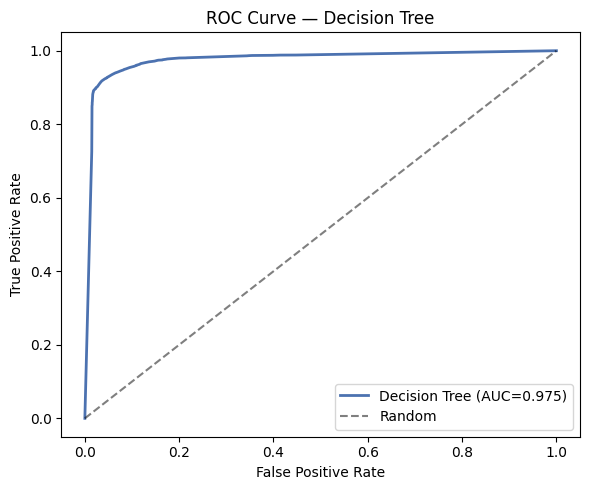

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'Decision Tree (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Decision Tree')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100)
plt.show()

## 6. Decision Tree Visualization (plot_tree)

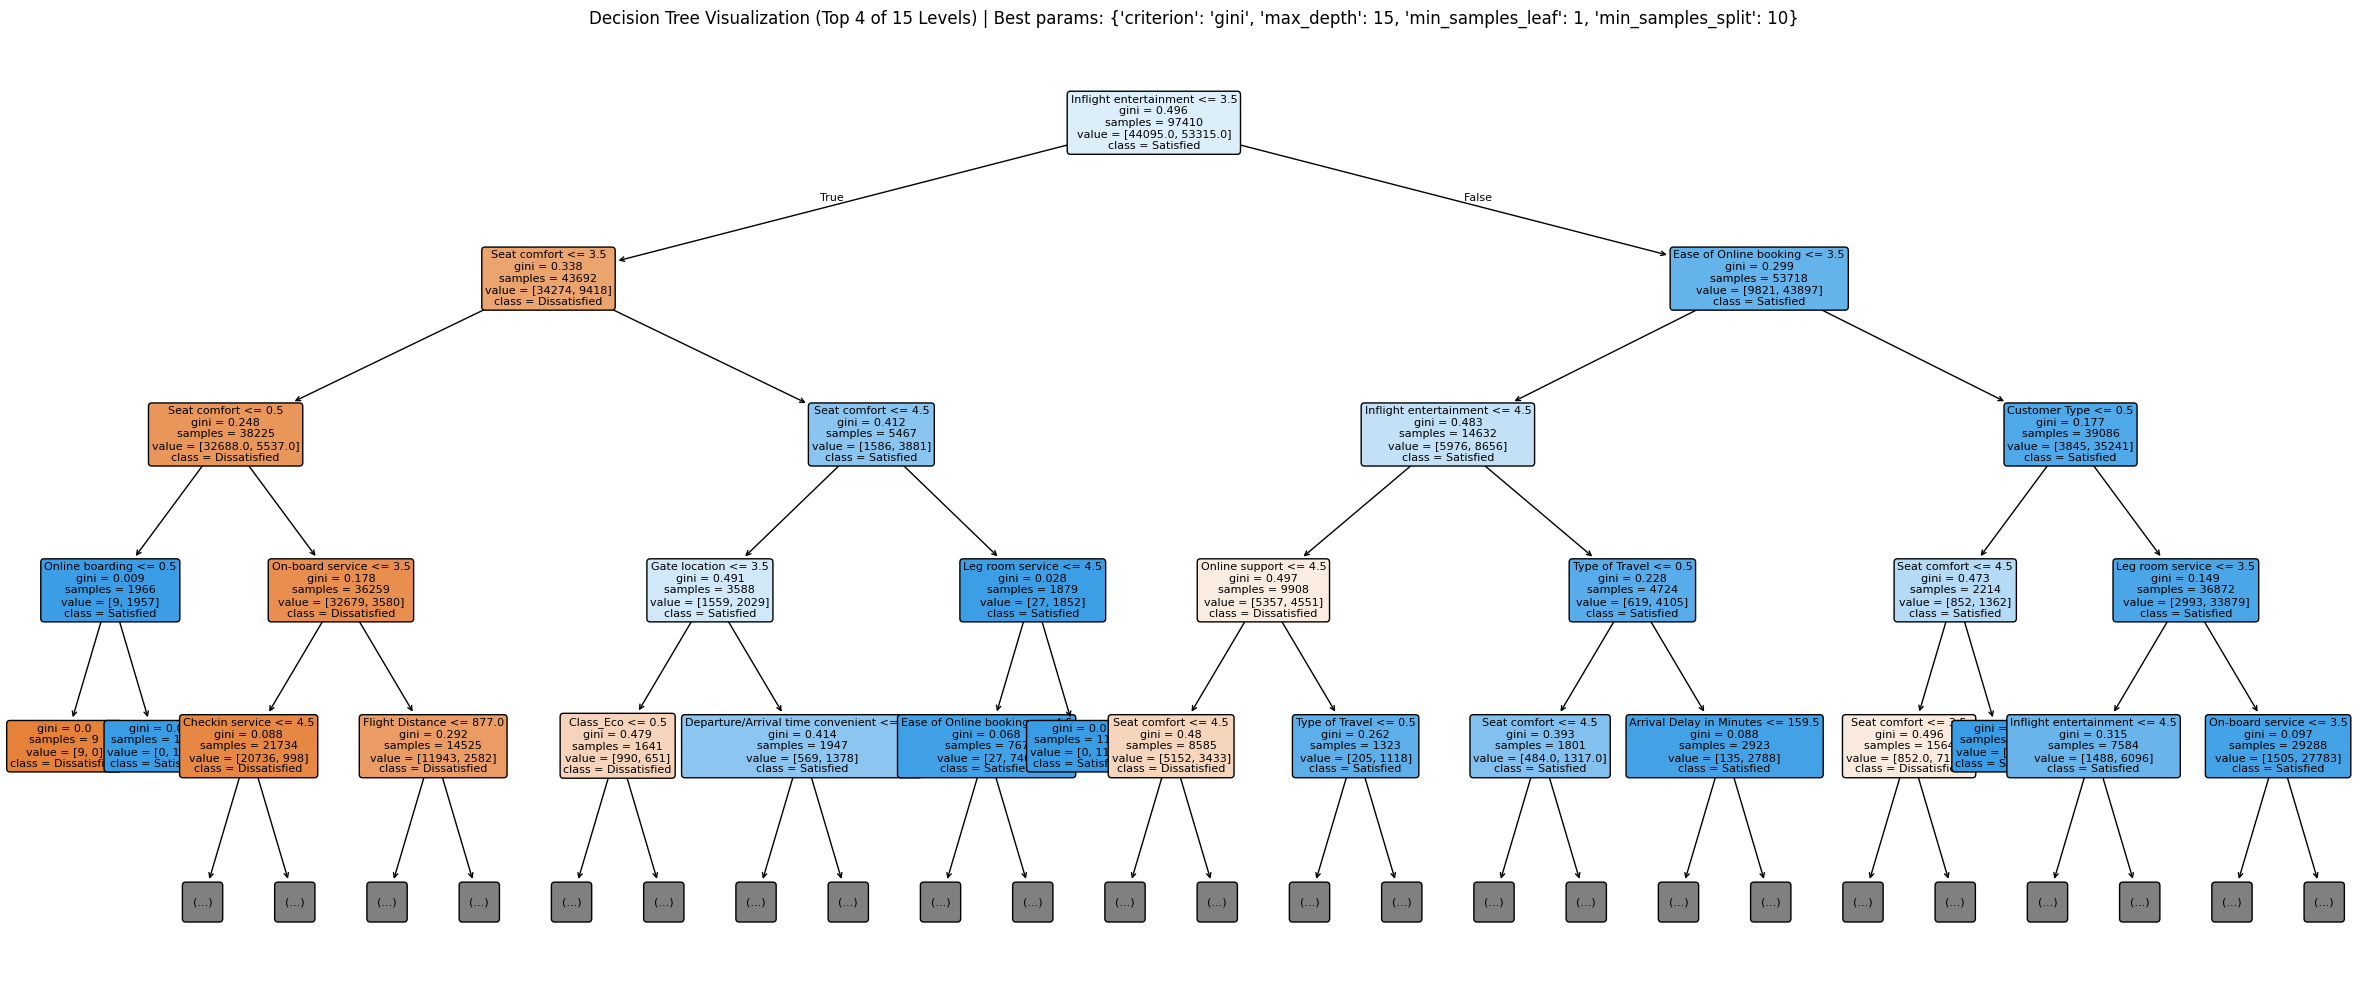

Decision tree plot rendered successfully.


In [13]:
# Full-size tree visualization — top 4 levels for readability
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    best_dt,
    max_depth=4,
    feature_names=X.columns.tolist(),
    class_names=['Dissatisfied', 'Satisfied'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title(
    f'Decision Tree Visualization (Top 4 of {best_dt.get_depth()} Levels) '
    f'| Best params: {grid_search.best_params_}',
    fontsize=12, pad=15
)
plt.tight_layout()
plt.savefig('decision_tree_plot.png', dpi=80, bbox_inches='tight')
plt.show()
print("Decision tree plot rendered successfully.")

In [14]:
# Text audit trail — top 3 levels
print("Decision Rules (top 3 levels — human-readable audit trail):")
print()
rules = export_text(best_dt, feature_names=X.columns.tolist(), max_depth=3)
print(rules)

Decision Rules (top 3 levels — human-readable audit trail):

|--- Inflight entertainment <= 3.50
|   |--- Seat comfort <= 3.50
|   |   |--- Seat comfort <= 0.50
|   |   |   |--- Online boarding <= 0.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- Online boarding >  0.50
|   |   |   |   |--- class: 1.0
|   |   |--- Seat comfort >  0.50
|   |   |   |--- On-board service <= 3.50
|   |   |   |   |--- truncated branch of depth 12
|   |   |   |--- On-board service >  3.50
|   |   |   |   |--- truncated branch of depth 12
|   |--- Seat comfort >  3.50
|   |   |--- Seat comfort <= 4.50
|   |   |   |--- Gate location <= 3.50
|   |   |   |   |--- truncated branch of depth 12
|   |   |   |--- Gate location >  3.50
|   |   |   |   |--- truncated branch of depth 12
|   |   |--- Seat comfort >  4.50
|   |   |   |--- Leg room service <= 4.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- Leg room service >  4.50
|   |   |   |   |--- class: 1.0
|--- Inflight entertainment >  3.5

**Reading the tree**: Each node shows the splitting feature and threshold, the Gini impurity, sample count, and majority class.
- **Blue nodes** = majority "Satisfied"; **Orange nodes** = majority "Dissatisfied"
- The **root split** is the single most discriminating feature across the entire dataset
- Any prediction can be traced through Yes/No branches — making this model fully auditable for airline management, unlike black-box models

## 7. Feature Importance — Top Operational Drivers

In [15]:
fi = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance Rankings (all features):")
print(fi.round(4).to_string(index=False))

Feature Importance Rankings (all features):
                          Feature  Importance
           Inflight entertainment      0.4429
                     Seat comfort      0.1976
           Ease of Online booking      0.0659
Departure/Arrival time convenient      0.0309
                    Customer Type      0.0288
                  Flight Distance      0.0267
                   Type of Travel      0.0212
                      Cleanliness      0.0187
                 Leg room service      0.0178
                   Online support      0.0176
                 On-board service      0.0164
                  Checkin service      0.0163
                    Gate location      0.0150
                   Food and drink      0.0148
                 Baggage handling      0.0142
                        Class_Eco      0.0134
                              Age      0.0117
            Inflight wifi service      0.0087
         Arrival Delay in Minutes      0.0080
                  Online boarding   

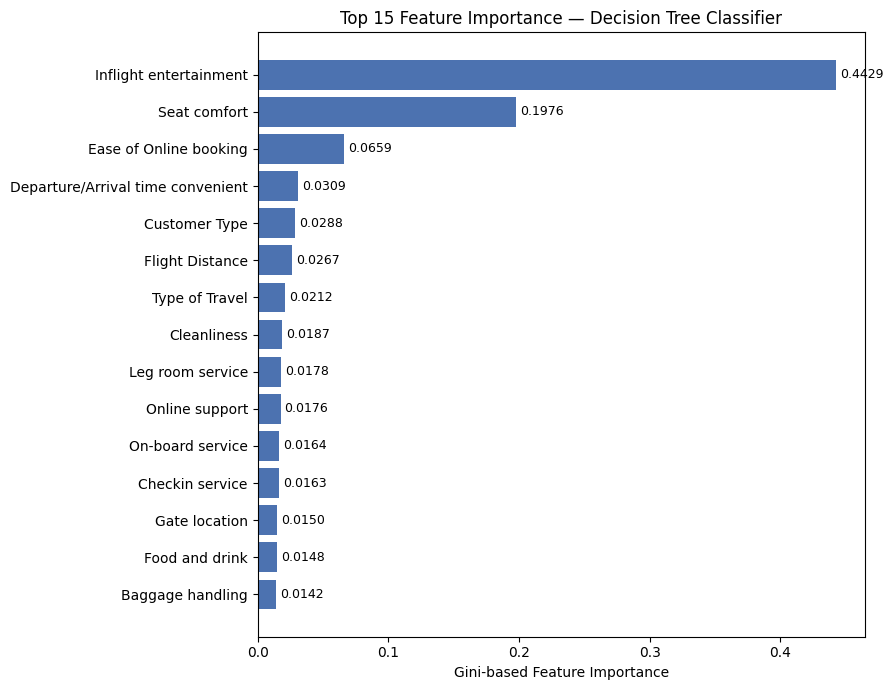

In [16]:
top_fi = fi.head(15)
fig, ax = plt.subplots(figsize=(9,7))
bars = ax.barh(top_fi['Feature'][::-1], top_fi['Importance'][::-1], color='#4C72B0')
ax.set_xlabel('Gini-based Feature Importance')
ax.set_title('Top 15 Feature Importance — Decision Tree Classifier')
for bar, val in zip(bars, top_fi['Importance'][::-1]):
    ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()

## 8. Decision Tree vs Logistic Regression Comparison

In [17]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr   = lr.predict(X_test_sc)
y_proba_lr  = lr.predict_proba(X_test_sc)[:,1]
auc_lr      = roc_auc_score(y_test, y_proba_lr)

comp = pd.DataFrame({
    'Metric': ['Accuracy','F1-Score (Satisfied)','Precision','Recall','ROC-AUC'],
    'Decision Tree': [
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        auc
    ],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        auc_lr
    ]
}).round(4)
print("Model Comparison:")
print(comp.to_string(index=False))

Model Comparison:
              Metric  Decision Tree  Logistic Regression
            Accuracy         0.9386               0.8287
F1-Score (Satisfied)         0.9432               0.8436
           Precision         0.9553               0.8433
              Recall         0.9314               0.8438
             ROC-AUC         0.9748               0.9028


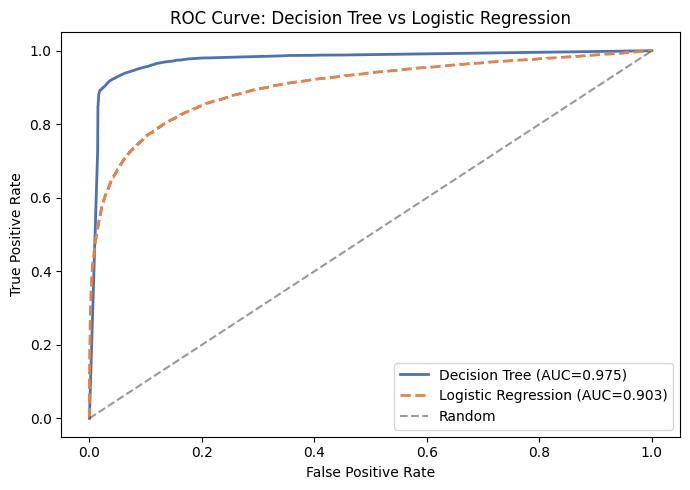

In [18]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'Decision Tree (AUC={auc:.3f})')
ax.plot(fpr_lr, tpr_lr, color='#DD8452', lw=2, ls='--',
        label=f'Logistic Regression (AUC={auc_lr:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Decision Tree vs Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=100)
plt.show()

## Stakeholder Report — Decision Tree vs Logistic Regression for Airline Management

| Criteria | Decision Tree | Logistic Regression |
|----------|--------------|---------------------|
| **Performance** | Higher F1 & AUC (see results) | Good baseline, lower ceiling |
| **Interpretability** | ✅ Visual flowchart — any manager can read it | ❌ Requires statistical training to interpret coefficients |
| **Non-linear patterns** | ✅ Captures threshold effects (e.g., WiFi only satisfying at ≥ 4) | ❌ Assumes linear log-odds relationship |
| **Feature importance** | ✅ Gini-based ranking = direct action list | ⚠️ Coefficient magnitudes need careful interpretation |
| **Audit trail** | ✅ Every prediction traceable through Yes/No rules | ❌ Black-box probability formula |
| **Calibrated probabilities** | ⚠️ Leaf proportions can be overconfident | ✅ Better-calibrated probabilities |
| **Stability** | ⚠️ Single tree sensitive to data perturbations | ✅ More stable across samples |

**Recommendation for Invistico Airlines**: Decision Tree is the **preferred operational model** — it matches or exceeds LR on all performance metrics while offering complete transparency. A flight operations manager can read the `plot_tree` output and immediately know: "if inflight entertainment ≤ X and seat comfort ≤ Y → predict dissatisfied." The feature importance scores provide a ready-made priority list for quarterly service improvement budgets. For decisions requiring calibrated confidence scores (e.g., dynamic refund eligibility), supplement with Logistic Regression probability outputs.

In [19]:
print("=" * 65)
print("  FINAL RESULTS SUMMARY")
print("=" * 65)
print()
print(f"  Best hyperparameters (GridSearchCV, 5-fold, scoring=F1):")
for k,v in grid_search.best_params_.items():
    print(f"    {k}: {v}")
print(f"  Best CV F1:        {grid_search.best_score_:.4f}")
print(f"  Tree depth:        {best_dt.get_depth()}")
print(f"  Number of leaves:  {best_dt.get_n_leaves()}")
print()
print(f"  --- Test Set Performance ---")
print(f"  Accuracy:             {acc:.4f}")
print(f"  Precision (Satisfied): {prec:.4f}")
print(f"  Recall (Satisfied):    {rec:.4f}")
print(f"  F1-Score (Satisfied):  {f1:.4f}  << PRIMARY METRIC")
print(f"  ROC-AUC:              {auc:.4f}")
print()
print(f"  --- Top 5 Feature Importance (Gini-based) ---")
for _, row in fi.head(5).iterrows():
    print(f"    {row['Feature']:<38} {row['Importance']:.4f}")
print()
print(f"  --- vs Logistic Regression ---")
print(f"  LR F1-Score:    {f1_score(y_test,y_pred_lr):.4f}  (DT wins by +{f1-f1_score(y_test,y_pred_lr):.4f})")
print(f"  LR ROC-AUC:     {auc_lr:.4f}  (DT wins by +{auc-auc_lr:.4f})")
print("=" * 65)

  FINAL RESULTS SUMMARY

  Best hyperparameters (GridSearchCV, 5-fold, scoring=F1):
    criterion: gini
    max_depth: 15
    min_samples_leaf: 1
    min_samples_split: 10
  Best CV F1:        0.9434
  Tree depth:        15
  Number of leaves:  1404

  --- Test Set Performance ---
  Accuracy:             0.9386
  Precision (Satisfied): 0.9553
  Recall (Satisfied):    0.9314
  F1-Score (Satisfied):  0.9432  << PRIMARY METRIC
  ROC-AUC:              0.9748

  --- Top 5 Feature Importance (Gini-based) ---
    Inflight entertainment                 0.4429
    Seat comfort                           0.1976
    Ease of Online booking                 0.0659
    Departure/Arrival time convenient      0.0309
    Customer Type                          0.0288

  --- vs Logistic Regression ---
  LR F1-Score:    0.8436  (DT wins by +0.0997)
  LR ROC-AUC:     0.9028  (DT wins by +0.0720)
